In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# FULL PyTorch pipeline

In [3]:
import os
import pandas as pd
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np

In [4]:
class BreastUltrasoundDataset(Dataset):
    """
    Robust PyTorch Dataset for breast ultrasound images with masks.

    Args:
        root_dir: Root directory containing split folders (e.g., 'train' or 'test')
        csv_file: Name of CSV file (e.g., 'metadata.csv')
        transform: Optional torchvision transforms
        target_size: Tuple (height, width) for resizing, default (256, 256)
    """

    def __init__(self, root_dir, csv_file='metadata.csv', transform=None, target_size=(256, 256)):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.target_size = target_size

        # 1. Define the Class Mapping (THIS WAS MISSING)
        self.class_to_idx = {
            "normal": 0,
            "benign": 1,
            "malignant": 2
        }
        # Create reverse mapping for the print statement in your main block
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

        # Load CSV metadata
        csv_path = self.root_dir / csv_file
        if not csv_path.exists():
            raise FileNotFoundError(f"CSV file not found: {csv_path}")

        self.metadata = pd.read_csv(csv_path)

        # Validate required columns
        required_cols = ['image_path', 'mask_path', 'class_name']
        missing_cols = [col for col in required_cols if col not in self.metadata.columns]
        if missing_cols:
            raise ValueError(f"CSV missing required columns: {missing_cols}")

        # Remove rows with missing paths
        initial_len = len(self.metadata)
        self.metadata = self.metadata.dropna(subset=['image_path', 'mask_path', 'class_name'])
        if len(self.metadata) < initial_len:
            print(f"Warning: Dropped {initial_len - len(self.metadata)} rows with missing values")

        self.metadata = self.metadata.reset_index(drop=True)

        # Validate that files exist
        self._validate_files()

    def _validate_files(self):
        """Validate that all image and mask files exist."""
        valid_indices = []

        for idx in range(len(self.metadata)):
            img_path = self._get_full_path(self.metadata.loc[idx, 'image_path'])
            mask_path = self._get_full_path(self.metadata.loc[idx, 'mask_path'])

            if img_path.exists() and mask_path.exists():
                valid_indices.append(idx)
            else:
                if not img_path.exists():
                    print(f"Warning: Image not found: {img_path}")
                if not mask_path.exists():
                    print(f"Warning: Mask not found: {mask_path}")

        initial_len = len(self.metadata)
        self.metadata = self.metadata.iloc[valid_indices].reset_index(drop=True)

        if len(self.metadata) == 0:
            raise RuntimeError("No valid image-mask pairs found!")

        if len(self.metadata) < initial_len:
            print(f"Dataset validated: {len(self.metadata)}/{initial_len} samples are valid")

    def _get_full_path(self, relative_path):
        """
        Construct full path from relative path in CSV.
        The CSV already contains folder prefix (e.g., 'images/normal_191.png'),
        so we only prepend the root directory.
        """
        # Convert to string and clean any extra separators
        rel_path = str(relative_path).strip()

        # Remove leading slashes that might cause issues
        rel_path = rel_path.lstrip('/')

        # Construct full path: root_dir / relative_path
        full_path = self.root_dir / rel_path

        return full_path

    def _load_image(self, path):
        """Load and preprocess image."""
        # 1. Load image (Default is BGR, shape: HxWx3)
        img = cv2.imread(str(path))

        if img is None:
            raise ValueError(f"Failed to load image: {path}")

        # 2. Convert BGR to RGB (Standard for PyTorch)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 3. Resize (Shape remains HxWx3)
        img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)

        # 4. Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0

        # 5. Transpose: Change from [Height, Width, Channel] -> [Channel, Height, Width]
        # This moves the '3' from the end to the front.
        img = np.transpose(img, (2, 0, 1))

        # 6. Convert to tensor
        # No 'expand_dims' needed because we already have 3 channels.
        return torch.from_numpy(img)

    def _load_mask(self, path):
        """Load and preprocess mask."""
        # Load mask (could be grayscale or RGB)
        mask = cv2.imread(str(path))

        if mask is None:
            raise ValueError(f"Failed to load mask: {path}")

        # Convert to grayscale if it's a 3-channel image
        if len(mask.shape) == 3 and mask.shape[2] == 3:
            # Take first channel (they should all be the same for masks)
            mask = mask[:,:,0]

        # Resize with nearest neighbor to preserve discrete values
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)

        # Binarize: threshold at 127 (assuming masks are 0 or 255)
        mask = (mask > 127).astype(np.float32)

        # Add channel dimension: [H, W] -> [1, H, W]
        mask = np.expand_dims(mask, axis=0)

        return torch.from_numpy(mask)

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):


      """
      Returns:
        image: Tensor of shape [1, H, W]
        mask: Tensor of shape [1, H, W]
        label: Tensor (single value)
      """
      if idx >= len(self.metadata):
          raise IndexError(f"Index {idx} out of range for dataset of size {len(self.metadata)}")

      # Get paths from CSV
      img_relative_path = self.metadata.loc[idx, 'image_path']
      mask_relative_path = self.metadata.loc[idx, 'mask_path']
      class_name = self.metadata.loc[idx, 'class_name']

      # Convert string class name to numeric label
      # Example: "benign" -> 0, "malignant" -> 1, "normal" -> 2
      class_name_str = str(class_name).strip()

      if class_name_str not in self.class_to_idx:
          raise ValueError(f"Unknown class '{class_name_str}' at index {idx}. "
                         f"Valid classes: {list(self.class_to_idx.keys())}")

      label = self.class_to_idx[class_name_str]

      # Construct full paths
      img_path = self._get_full_path(img_relative_path)
      mask_path = self._get_full_path(mask_relative_path)

      # Load image and mask
      try:
          image = self._load_image(img_path)
          mask = self._load_mask(mask_path)
      except Exception as e:
          raise RuntimeError(f"Error loading sample {idx}: {e}\n"
                         f"Image path: {img_path}\n"
                         f"Mask path: {mask_path}")

    # Apply transforms if provided (after converting to tensor)
      if self.transform:
          image = self.transform(image)

      # Convert numeric label to tensor
      label = torch.tensor(label, dtype=torch.long)

      return image, mask, label


In [5]:

train_dataset = BreastUltrasoundDataset(
        root_dir='/content/drive/MyDrive/DL_Datasets/Merged_Dataset_rm_artifact/train',
        csv_file='train_metadata.csv',
        target_size=(256, 256)
    )

test_dataset = BreastUltrasoundDataset(
    root_dir='/content/drive/MyDrive/DL_Datasets/Merged_Dataset_rm_artifact/test',
    csv_file="test_metadata.csv",
    target_size=(256, 256)
)


In [6]:
print(f"Dataset size: {len(train_dataset)}")
print(f"Class mapping: {train_dataset.class_to_idx}")
print(f"Index to class: {train_dataset.idx_to_class}")

Dataset size: 2577
Class mapping: {'normal': 0, 'benign': 1, 'malignant': 2}
Index to class: {0: 'normal', 1: 'benign', 2: 'malignant'}


In [74]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,   # batch-level shuffle
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [30]:
for batch_idx, (images, masks, labels) in enumerate(train_loader):
        print(f"\nBatch {batch_idx}:")
        print(f"  Images shape: {images.shape}")  # [B, 1, H, W]
        print(f"  Masks shape: {masks.shape}")    # [B, 1, H, W]
        print(f"  Labels shape: {labels.shape}")  # [B]
        print(f"  Image range: [{images.min():.3f}, {images.max():.3f}]")
        print(f"  Mask unique values: {masks.unique()}")

        if batch_idx == 0:  # Only show first batch
            break


Batch 0:
  Images shape: torch.Size([8, 3, 256, 256])
  Masks shape: torch.Size([8, 1, 256, 256])
  Labels shape: torch.Size([8])
  Image range: [0.000, 1.000]
  Mask unique values: tensor([0., 1.])


# Build The Model

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import distance_transform_edt, binary_erosion, generate_binary_structure
from sklearn.metrics import f1_score

In [54]:
class EfficientNetEncoder(nn.Module):
    def __init__(self, name="efficientnet_b0", pretrained=True):
        super().__init__()
        self.encoder = timm.create_model(
            name,
            pretrained=pretrained,
            features_only=True,
            out_indices=(1, 2, 3, 4)
        )

    def forward(self, x):
        return self.encoder(x)  # list of feature maps


In [55]:
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


In [56]:
class UNetDecoder(nn.Module):
    def __init__(self, encoder_channels):
        super().__init__()

        self.d4 = DecoderBlock(encoder_channels[3], encoder_channels[2], 256)
        self.d3 = DecoderBlock(256, encoder_channels[1], 128)
        self.d2 = DecoderBlock(128, encoder_channels[0], 64)

        self.seg_head = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, feats):
        x1, x2, x3, x4 = feats

        d4 = self.d4(x4, x3)
        d3 = self.d3(d4, x2)
        d2 = self.d2(d3, x1)

        mask = self.seg_head(d2)
        return mask, d2


In [57]:
class BoundaryAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Conv2d(1, in_channels, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, features, seg_mask):
        """
        features: decoder feature map (B,C,H,W)
        seg_mask: predicted mask (B,1,H,W)
        """
        boundary_att = self.attention(seg_mask)
        return features * boundary_att


In [58]:
class ClassificationHead(nn.Module):
    def __init__(self, in_channels, num_classes=3):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.pool(x).flatten(1)
        return self.fc(x)


In [59]:
class MultiTaskBoundaryUNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.encoder = EfficientNetEncoder()
        encoder_channels = self.encoder.encoder.feature_info.channels()

        self.decoder = UNetDecoder(encoder_channels)
        self.boundary_att = BoundaryAttention(in_channels=64)
        self.classifier = ClassificationHead(64, num_classes)

    def forward(self, x):
        feats = self.encoder(x)

        seg_mask, decoder_feats = self.decoder(feats)
        seg_mask_sigmoid = torch.sigmoid(seg_mask)

        boundary_feats = self.boundary_att(decoder_feats, seg_mask_sigmoid)
        class_logits = self.classifier(boundary_feats)

        return {
            "segmentation": seg_mask,
            "classification": class_logits
        }


# Loss

In [60]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.view(preds.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (preds * targets).sum(1)
        dice = (2. * intersection + self.smooth) / (
            preds.sum(1) + targets.sum(1) + self.smooth
        )
        return 1 - dice.mean()


In [61]:
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

In [62]:
cls_loss_fn = nn.CrossEntropyLoss()

# Metrices

In [63]:
def dice_score(preds, targets, threshold=0.5):
    preds = torch.sigmoid(preds) > threshold
    preds = preds.float()

    intersection = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))

    dice = (2 * intersection + 1e-6) / (union + 1e-6)
    return dice.mean().item()


In [64]:
from sklearn.metrics import f1_score

def compute_macro_f1(preds, targets):
    preds = torch.argmax(preds, dim=1).cpu().numpy()
    targets = targets.cpu().numpy()
    return f1_score(targets, preds, average="macro")


In [65]:
def compute_accuracy(preds, targets):
    """
    preds: [Batch, Num_Classes] (Logits)
    targets: [Batch] (Indices)
    """
    # Get the class with the highest score
    pred_labels = torch.argmax(preds, dim=1)

    # Check equality with ground truth
    correct = (pred_labels == targets).sum().item()

    # Return percentage
    return correct / len(targets)

In [66]:
def dice_score_batch(preds, targets, threshold=0.5):
    """
    Computes DSC (Dice Similarity Coefficient).
    preds: Logits [B, 1, H, W]
    targets: Binary Mask [B, 1, H, W]
    """
    preds = (torch.sigmoid(preds) > threshold).float()

    intersection = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))

    # Add epsilon to avoid division by zero
    dice = (2 * intersection + 1e-6) / (union + 1e-6)
    return dice.mean().item()

In [67]:
def compute_normalized_surface_dice(pred_tensor, gt_tensor, threshold=0.5, tolerance=2.0):
    """
    Computes Normalized Surface Dice (NSD).
    Input: PyTorch Tensors [B, 1, H, W]
    Output: Average NSD score (0.0 to 1.0)
    """
    # Convert to numpy for scipy processing
    pred_np = (torch.sigmoid(pred_tensor) > threshold).cpu().numpy().astype(bool)
    gt_np = gt_tensor.cpu().numpy().astype(bool)

    batch_size = pred_np.shape[0]
    nsd_scores = []

    # 4-connectivity structure for finding boundaries
    struct = generate_binary_structure(2, 1)

    for i in range(batch_size):
        pred = pred_np[i, 0]
        gt = gt_np[i, 0]

        # Edge case: Both empty
        if not np.any(pred) and not np.any(gt):
            nsd_scores.append(1.0)
            continue
        # Edge case: One empty
        if not np.any(pred) or not np.any(gt):
            nsd_scores.append(0.0)
            continue

        # 1. Get Boundaries (XOR with eroded version)
        pred_border = pred ^ binary_erosion(pred, structure=struct)
        gt_border = gt ^ binary_erosion(gt, structure=struct)

        # 2. Compute Distance Transforms
        dt_gt = distance_transform_edt(~gt_border)
        dt_pred = distance_transform_edt(~pred_border)

        # 3. Calculate Agreement (pixels within tolerance)
        # Fraction of pred border within tolerance of gt border
        buffer_gt = dt_gt[pred_border]
        if len(buffer_gt) == 0: precision = 0.0
        else: precision = np.mean(buffer_gt <= tolerance)

        # Fraction of gt border within tolerance of pred border
        buffer_pred = dt_pred[gt_border]
        if len(buffer_pred) == 0: recall = 0.0
        else: recall = np.mean(buffer_pred <= tolerance)

        # 4. Harmonic Mean (Dice-like)
        if precision + recall == 0:
            nsd = 0.0
        else:
            nsd = (2 * precision * recall) / (precision + recall)

        nsd_scores.append(nsd)

    return np.mean(nsd_scores)

# Training Loop

In [68]:
def train_one_epoch(model, loader, optimizer, device, lambda_cls=0.4):
    model.train()

    total_loss = 0
    total_dice = 0
    total_nsd = 0  # <--- NEW
    total_f1 = 0
    total_acc = 0

    # Timing
    start_time = time.time()

    loop = tqdm(loader, desc="Train", leave=False)

    for batch in loop:
        images = batch[0].to(device)
        masks = batch[1].to(device)
        labels = batch[2].to(device)

        optimizer.zero_grad()

        # --- Forward Pass ---
        outputs = model(images)
        seg_logits = outputs["segmentation"]
        cls_logits = outputs["classification"]

        # Resize logits if necessary
        if seg_logits.shape[-2:] != masks.shape[-2:]:
            seg_logits = F.interpolate(seg_logits, size=masks.shape[-2:], mode='bilinear', align_corners=False)

        # --- Loss Calculation ---
        loss_seg = bce_loss(seg_logits, masks) + dice_loss(seg_logits, masks)
        loss_cls = cls_loss_fn(cls_logits, labels)
        loss = loss_seg + lambda_cls * loss_cls

        # --- Backward Pass ---
        loss.backward()
        optimizer.step()

        # --- Metrics & Tracking ---
        total_loss += loss.item()

        # Detach for metrics to save memory
        seg_detached = seg_logits.detach()
        cls_detached = cls_logits.detach()

        total_dice += dice_score_batch(seg_detached, masks)
        # Note: NSD is computationally heavy, so we calculate it here, but
        # for huge datasets, you might only do it during validation.
        total_nsd += compute_normalized_surface_dice(seg_detached, masks)

        total_f1 += compute_macro_f1(cls_detached, labels)
        total_acc += compute_accuracy(cls_detached, labels)

        loop.set_postfix(loss=loss.item())

    end_time = time.time()
    n = len(loader)

    return {
        "loss": total_loss / n,
        "dsc": total_dice / n,      # Renamed to DSC
        "nsd": total_nsd / n,       # Added NSD
        "f1": total_f1 / n,
        "acc": total_acc / n,
        "time": end_time - start_time
    }

# Evaluation Loop

In [69]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    total_dice = 0
    total_nsd = 0
    all_preds = []
    all_labels = []

    start_time = time.time() # Start Timer

    for batch in loader:
        images = batch[0].to(device)
        masks = batch[1].to(device)
        labels = batch[2].to(device)

        # Inference
        outputs = model(images)
        seg_logits = outputs["segmentation"]
        cls_logits = outputs["classification"]

        # Resize
        if seg_logits.shape[-2:] != masks.shape[-2:]:
            seg_logits = F.interpolate(seg_logits, size=masks.shape[-2:], mode='bilinear', align_corners=False)

        # Metrics per batch
        total_dice += dice_score_batch(seg_logits, masks)
        total_nsd += compute_normalized_surface_dice(seg_logits, masks)

        all_preds.append(cls_logits)
        all_labels.append(labels)

    end_time = time.time() # End Timer

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Classification Metrics on full set
    f1 = compute_macro_f1(all_preds, all_labels)
    acc = compute_accuracy(all_preds, all_labels)

    avg_inference_speed = (end_time - start_time) / len(loader.dataset)

    return {
        "dsc": total_dice / len(loader),
        "nsd": total_nsd / len(loader),
        "f1": f1,
        "acc": acc,
        "total_time": end_time - start_time,
        "avg_speed": avg_inference_speed
    }

# Full training script

In [70]:
from tqdm.notebook import tqdm

In [71]:
def visualize_results(model, loader, device, idx_to_class, num_samples=3):
    model.eval()
    batch = next(iter(loader))
    images, masks, labels = batch[0].to(device), batch[1].to(device), batch[2].to(device)

    with torch.no_grad():
        outputs = model(images)
        seg_logits = outputs["segmentation"]
        cls_logits = outputs["classification"]

        # Resize logic
        if seg_logits.shape[-2:] != masks.shape[-2:]:
             seg_logits = F.interpolate(seg_logits, size=masks.shape[-2:], mode='bilinear')

    # Prepare predictions
    pred_masks = (torch.sigmoid(seg_logits) > 0.5).float().cpu().numpy()
    pred_labels = torch.argmax(cls_logits, dim=1).cpu().numpy()

    # Prepare GT
    images_np = images.cpu().permute(0, 2, 3, 1).numpy() # (B, H, W, 3)
    masks_np = masks.cpu().numpy()
    labels_np = labels.cpu().numpy()

    # Plotting
    plt.figure(figsize=(15, 5 * num_samples))
    for i in range(num_samples):
        # 1. Input Image
        plt.subplot(num_samples, 4, i*4 + 1)
        # Un-normalize if you normalized (assuming 0-1 range here)
        plt.imshow(images_np[i])
        plt.title(f"Input Sample {i+1}")
        plt.axis("off")

        # 2. GT Mask
        plt.subplot(num_samples, 4, i*4 + 2)
        plt.imshow(masks_np[i, 0], cmap="gray")
        plt.title(f"GT Mask\nClass: {idx_to_class[labels_np[i]]}")
        plt.axis("off")

        # 3. Predicted Mask
        plt.subplot(num_samples, 4, i*4 + 3)
        plt.imshow(pred_masks[i, 0], cmap="gray")
        plt.title(f"Pred Mask\nNSD: {compute_normalized_surface_dice(seg_logits[i:i+1], masks[i:i+1]):.2f}")
        plt.axis("off")

        # 4. Overlay/Status
        plt.subplot(num_samples, 4, i*4 + 4)
        status = "CORRECT" if pred_labels[i] == labels_np[i] else "WRONG"
        color = "green" if status == "CORRECT" else "red"

        plt.text(0.5, 0.5,
                 f"Pred: {idx_to_class[pred_labels[i]]}\n"
                 f"GT: {idx_to_class[labels_np[i]]}\n\n"
                 f"[{status}]",
                 horizontalalignment='center',
                 verticalalignment='center',
                 fontsize=14, color=color,
                 bbox=dict(facecolor='white', alpha=0.8))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

      Multi-Task Training Started (5 Epochs)



Epoch [1/5]
  [Train] Loss: 1.5471 | Time: 410.74s
          Seg : DSC 0.4947 | NSD 0.2184
          Cls : F1  0.3887  | Acc 0.5166


Train:   0%|          | 0/323 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Epoch [2/5]
  [Train] Loss: 1.1750 | Time: 74.46s
          Seg : DSC 0.6781 | NSD 0.3675
          Cls : F1  0.5500  | Acc 0.6498


Train:   0%|          | 0/323 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


...

Train:   0%|          | 0/323 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                                   


Epoch [5/5]
  [Train] Loss: 0.7160 | Time: 73.72s
          Seg : DSC 0.8486 | NSD 0.5894
          Cls : F1  0.8491  | Acc 0.8793

             Final Evaluation (Test Set)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Total Inference Time: 137.84s
Avg Speed per Image : 470.43 ms

--- Segmentation Results ---
  DSC (Region Error) : 0.7898
  NSD (Surface Error): 0.5971

--- Classification Results ---
  Macro F1-Score     : 0.8531
  Accuracy           : 0.8737

             Visualizing Predictions


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


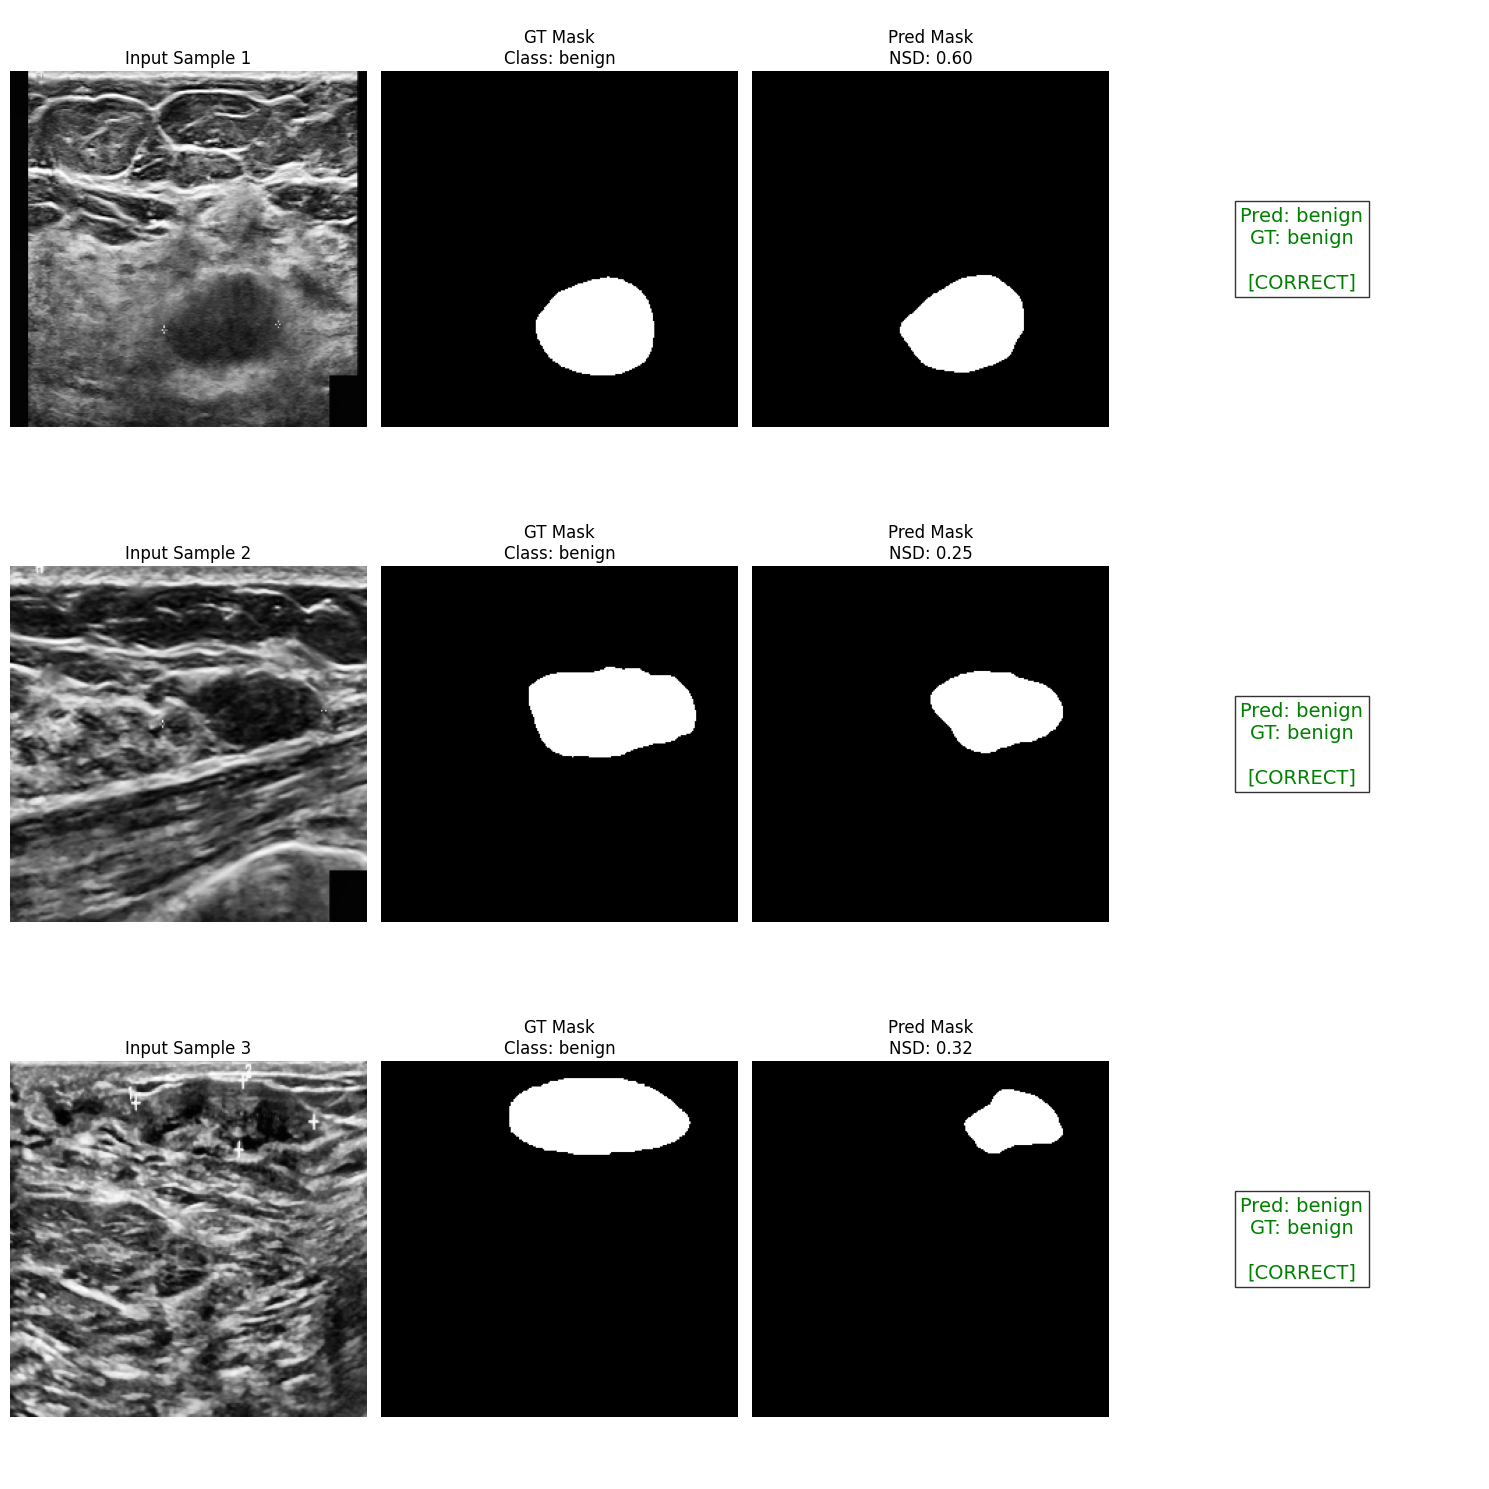

In [75]:
from tqdm import tqdm
import torch.nn.functional as F  # Ensure this is imported for the resize fix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiTaskBoundaryUNet(num_classes=3).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

num_epochs = 5

# Assuming 'train_dataset' and 'train_loader' are already defined from previous code
# And 'idx_to_class' is available from train_dataset.idx_to_class

print("=======================================================")
print(f"      Multi-Task Training Started ({num_epochs} Epochs)")
print("=======================================================")

for epoch in range(num_epochs):
    # --- TRAIN ---
    train_metrics = train_one_epoch(model, train_loader, optimizer, device)

    # Clean Print
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"  [Train] Loss: {train_metrics['loss']:.4f} | Time: {train_metrics['time']:.2f}s")
    print(f"          Seg : DSC {train_metrics['dsc']:.4f} | NSD {train_metrics['nsd']:.4f}")
    print(f"          Cls : F1  {train_metrics['f1']:.4f}  | Acc {train_metrics['acc']:.4f}")

# --- TEST ---
print("\n=======================================================")
print("             Final Evaluation (Test Set)")
print("=======================================================")

test_metrics = evaluate(model, test_loader, device)

print(f"Total Inference Time: {test_metrics['total_time']:.2f}s")
print(f"Avg Speed per Image : {test_metrics['avg_speed']*1000:.2f} ms\n")

print("--- Segmentation Results ---")
print(f"  DSC (Region Error) : {test_metrics['dsc']:.4f}")
print(f"  NSD (Surface Error): {test_metrics['nsd']:.4f}")

print("\n--- Classification Results ---")
print(f"  Macro F1-Score     : {test_metrics['f1']:.4f}")
print(f"  Accuracy           : {test_metrics['acc']:.4f}")

# --- VISUALIZATION ---
print("\n=======================================================")
print("             Visualizing Predictions")
print("=======================================================")
# Ensure idx_to_class is available
visualize_results(model, test_loader, device, train_dataset.idx_to_class, num_samples=3)